# 02 — ETL: `staging` → `dwh`

Construye el modelo en estrella: 6 dimensiones + 2 hechos.
Cada paso del ETL queda separado de su verificación correspondiente.

## 0. Setup

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from src.etl.load import run_sql_directory

In [2]:
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
PALETTE = sns.color_palette('crest', as_cmap=False)

ROOT = Path('..')
SQL_SCHEMA = ROOT / 'sql' / '02_dwh_schema'
SQL_LOAD   = ROOT / 'sql' / '03_transformations'

## 1. DDL del DWH

Crea las dimensiones y los hechos vacíos.

In [3]:
run_sql_directory(SQL_SCHEMA)

22:03:01 [INFO] etl.load — Ejecutando 00_create_schema.sql
22:03:01 [INFO] etl.load — Ejecutando 10_dim_tables.sql
22:03:01 [INFO] etl.load — Ejecutando 20_fact_tables.sql


[PosixPath('../sql/02_dwh_schema/00_create_schema.sql'),
 PosixPath('../sql/02_dwh_schema/10_dim_tables.sql'),
 PosixPath('../sql/02_dwh_schema/20_fact_tables.sql')]

## 2. Carga de dimensiones y hechos

Pobla las dimensiones desde `staging` y luego los hechos referenciando las SK.

In [4]:
run_sql_directory(SQL_LOAD)

22:03:01 [INFO] etl.load — Ejecutando 10_load_dim_date.sql
22:03:01 [INFO] etl.load — Ejecutando 20_load_dim_customer.sql
22:03:01 [INFO] etl.load — Ejecutando 30_load_dim_product.sql
22:03:01 [INFO] etl.load — Ejecutando 40_load_dim_store.sql
22:03:02 [INFO] etl.load — Ejecutando 50_load_dim_misc.sql
22:03:02 [INFO] etl.load — Ejecutando 60_load_fact_sales.sql
22:03:02 [INFO] etl.load — Ejecutando 70_load_fact_returns.sql


[PosixPath('../sql/03_transformations/10_load_dim_date.sql'),
 PosixPath('../sql/03_transformations/20_load_dim_customer.sql'),
 PosixPath('../sql/03_transformations/30_load_dim_product.sql'),
 PosixPath('../sql/03_transformations/40_load_dim_store.sql'),
 PosixPath('../sql/03_transformations/50_load_dim_misc.sql'),
 PosixPath('../sql/03_transformations/60_load_fact_sales.sql'),
 PosixPath('../sql/03_transformations/70_load_fact_returns.sql')]

## 3. Verificación de filas

### 3.1. Conteos por tabla — SQL

In [5]:
%%sql
select 'dim_date'           as table_name, count(*) as rows from dwh.dim_date          union all
select 'dim_customer',         count(*) from dwh.dim_customer       union all
select 'dim_product',          count(*) from dwh.dim_product        union all
select 'dim_store',            count(*) from dwh.dim_store          union all
select 'dim_offer',            count(*) from dwh.dim_offer          union all
select 'dim_return_reason',    count(*) from dwh.dim_return_reason  union all
select 'fact_sales',           count(*) from dwh.fact_sales         union all
select 'fact_returns',         count(*) from dwh.fact_returns
order by rows desc

,table_name,rows
0,fact_sales,42555
1,dim_customer,5750
2,fact_returns,2330
3,dim_date,2230
4,dim_product,50
5,dim_store,20
6,dim_return_reason,6
7,dim_offer,1


## 4. Integridad referencial

Verificamos que ningún hecho tiene FK a NULL inesperada (cliente, producto o tienda).

### 4.1. Nulos en FKs de `fact_sales` — SQL

In [6]:
%%sql
select sum((customer_sk is null)::int) as cust_null,
       sum((product_sk  is null)::int) as prod_null,
       sum((store_sk    is null)::int) as store_null,
       count(*)                        as total
from dwh.fact_sales

,cust_null,prod_null,store_null,total
0,0,0,0,42555


### 4.2. Nulos en FKs de `fact_returns` — SQL

In [7]:
%%sql
select sum((customer_sk    is null)::int) as cust_null,
       sum((product_sk     is null)::int) as prod_null,
       sum((reason_sk      is null)::int) as reason_null,
       count(*)                           as total
from dwh.fact_returns

,cust_null,prod_null,reason_null,total
0,0,0,0,2330


## 5. Cobertura temporal de los hechos

Distribución anual de ventas y devoluciones para detectar cohortes incompletas.

### 5.1. Tickets y devoluciones por año — SQL

In [8]:
%%sql
select d.year::int                          as year,
       count(distinct f.sale_id)            as n_sales,
       count(*) filter (where r.return_id is not null) as n_returns
from dwh.fact_sales f
join dwh.dim_date d on d.date_id = f.sale_date_id
left join dwh.fact_returns r on r.sale_item_id = f.sale_item_id
group by d.year
order by d.year

,year,n_sales,n_returns
0,2020,2509,294
1,2021,3151,377
2,2022,3509,393
3,2023,3357,419
4,2024,3602,420
5,2025,3872,427


### 5.2. Visualización — series anuales

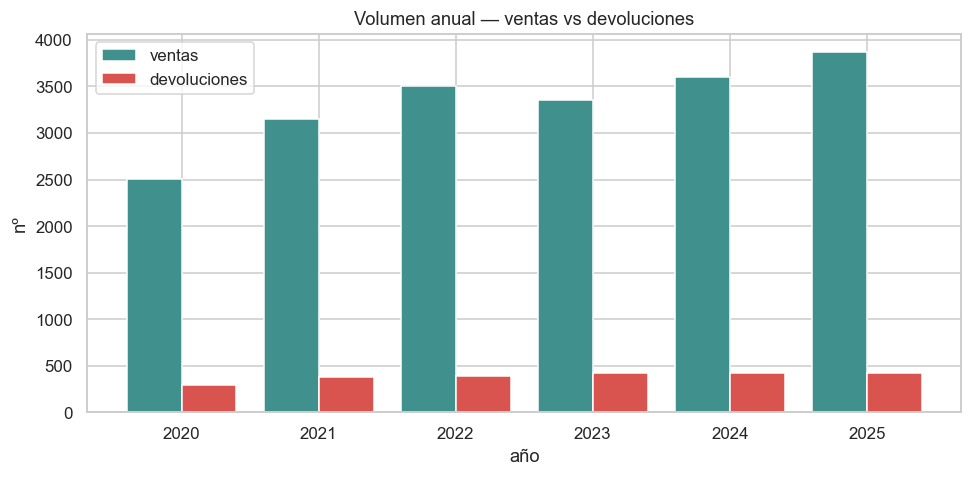

,year,n_sales,n_returns
0,2020,2509,294
1,2021,3151,377
2,2022,3509,393
3,2023,3357,419
4,2024,3602,420
5,2025,3872,427


In [9]:
yf = yearly_facts.copy()
yf['year'] = yf['year'].astype(int)
yf['n_sales'] = yf['n_sales'].astype(int)
yf['n_returns'] = yf['n_returns'].astype(int)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(yf['year'] - 0.2, yf['n_sales'],   width=0.4, label='ventas',      color=PALETTE[2])
ax.bar(yf['year'] + 0.2, yf['n_returns'], width=0.4, label='devoluciones', color='#d9534f')
ax.set_xticks(yf['year'])
ax.set_xlabel('año')
ax.set_ylabel('nº')
ax.set_title('Volumen anual — ventas vs devoluciones')
ax.legend()
plt.tight_layout()
plt.show()

yf